### 失败后恢复运行

#### 失败时到底发生了什么

节点抛异常时，LangGraph 的行为可以概括成三句话：

1. **异常直接抛给调用方** —— `invoke()` 不返回任何 state，你能拿到的只有 traceback。
2. **故障前的进度已经落盘** —— 每个 super-step **开始前**都会先 `put()` 一个 checkpoint，所以「上一步完成时的现场」是安全的。
3. **失败那一步的产出被丢弃** —— 它没写进 channel，只在 `pending_writes` 里留了一条 `__error__`。

所以 `try/except` 抓到异常 ≠ 白跑，**checkpointer 里存着可以续跑的断点**：

| 你想做什么 | 怎么做 |
| --- | --- |
| 看失败现场 | `agent.get_state(config)` |
| 找出是哪个节点挂的 | `snapshot.tasks[i].error` |
| 修好后从断点继续 | `agent.invoke(None, config)` |
| 回到更早一步重来 | 把旧 `checkpoint_id` 传给 `get_state` / `invoke` |
| 彻底清空重来 | `checkpointer.delete_thread(thread_id)` |

> 下面的示例全部用**确定性的假节点**，不调 LLM、不花钱，跑一遍就能看到完整链路。

In [1]:
import os

from dotenv import load_dotenv
from psycopg import connect
from psycopg.rows import dict_row
from langgraph.checkpoint.postgres import PostgresSaver
from langgraph.graph import MessagesState, START, StateGraph

load_dotenv(override=True)

_checkpointer: PostgresSaver | None = None


def get_checkpointer() -> PostgresSaver:
    """单例持有 PostgresSaver：连接随进程存活，setup 只在首次执行（详见 01）。"""
    global _checkpointer
    if _checkpointer is None:
        conn = connect(
            os.environ["POSTGRES_CONN_STRING"],
            autocommit=True,
            prepare_threshold=0,
            row_factory=dict_row,
        )
        _checkpointer = PostgresSaver(conn)
        _checkpointer.setup()
    return _checkpointer

#### 实验 1：一个节点抛异常

图结构 `START → a → b → c`，让 `b` 在开关打开时炸掉：

In [2]:
FAIL = {"on": True}          # 开关：模拟「外部依赖时好时坏」


def node_a(state):
    return {"messages": [("assistant", "A 的结果")]}


def node_b(state):
    if FAIL["on"]:
        raise RuntimeError("外部依赖挂了")   # 真实场景：API 超时、DB 连不上、解析失败
    return {"messages": [("assistant", "B 的结果")]}


def node_c(state):
    return {"messages": [("assistant", "C 的结果")]}


sb = StateGraph(MessagesState)
sb.add_node("a", node_a)
sb.add_node("b", node_b)
sb.add_node("c", node_c)
sb.add_edge(START, "a")
sb.add_edge("a", "b")
sb.add_edge("b", "c")

agent = sb.compile(checkpointer=get_checkpointer())
cfg = {"configurable": {"thread_id": "fail-1"}}
get_checkpointer().delete_thread("fail-1")   # 清掉上次运行的残留，保证每次从零开始

try:
    agent.invoke({"messages": [("user", "hi")]}, cfg)
except Exception as e:
    print("invoke 抛出：", type(e).__name__, "-", e)

print("注意：异常时拿不到返回值，只能靠下面的 get_state 看现场")

invoke 抛出： RuntimeError - 外部依赖挂了
注意：异常时拿不到返回值，只能靠下面的 get_state 看现场


#### 看现场：`get_state()` 拿到断点

异常发生时**不要急着重跑**，先看 LangGraph 停在哪：

In [3]:
snapshot = agent.get_state(cfg)

print("下一个待执行节点 next =", snapshot.next)          # ('b',) → 正是挂掉的那个
print("已保存的消息 =", [m.content for m in snapshot.values["messages"]])  # a 的结果还在
print("metadata step =", snapshot.metadata.get("step"), "，source =", snapshot.metadata.get("source"))

for t in snapshot.tasks:
    # 注意：error 是 str（异常的 repr），不是异常对象
    print(f"任务 {t.name}: error = {t.error!r}")

下一个待执行节点 next = ('b',)
已保存的消息 = ['hi', 'A 的结果']
metadata step = 1 ，source = loop
任务 b: error = "RuntimeError('外部依赖挂了')"


这里三个字段是判断的关键：

- **`next = ('b',)`** —— 断点位置。LangGraph 告诉你「该从哪继续」。
- **`messages` 里已经有 `A 的结果`** —— 说明 `a` 的产出**已经落盘**，不会因为 `b` 挂了而丢失。
- **`tasks[0].error` 是 `str`**（形如 `"RuntimeError('外部依赖挂了')"`），不是异常对象，没法直接 `except` 它，只能打印或字符串匹配。

也就是说：**失败那一步没留下任何东西，但之前的每一步都完好**。

#### 修好后续跑：`invoke(None, config)`

`input=None` 是「沿用已保存的状态」——LangGraph 从断点接着跑，**已完成的节点不会重跑**：

In [4]:
FAIL["on"] = False           # 修好外部依赖

result = agent.invoke(None, cfg)   # input=None → 沿用 checkpoint 续跑
print("续跑结果 =", [m.content for m in result["messages"]])

# 验证 a 没有被重跑：消息数应当是 4（hi / A / B / C），A 只出现一次
contents = [m.content for m in result["messages"]]
print("A 出现次数 =", contents.count("A 的结果"), "（1 = 没重跑）")
print("检查点条数 =", len(list(get_checkpointer().list(cfg))))

续跑结果 = ['hi', 'A 的结果', 'B 的结果', 'C 的结果']
A 出现次数 = 1 （1 = 没重跑）
检查点条数 = 5


#### 对照组：没挂 checkpointer 时会怎样

同样让 `b` 挂掉，但 `compile()` 不传 `checkpointer`：

In [5]:
FAIL["on"] = True            # 先重新打开开关，否则 b 直接跑成功、演示不出失败
plain = sb.compile()          # 没有 checkpointer
try:
    plain.invoke({"messages": [("user", "hi")]})
except Exception as e:
    print("invoke 抛出：", type(e).__name__, "-", e)

try:
    plain.get_state({"configurable": {"thread_id": "x"}})
except Exception as e:
    print("get_state 抛出：", type(e).__name__, "-", e)   # ValueError: No checkpointer set

# 结论：没有 checkpointer = 没有断点 = 只能整个重跑，之前所有步骤的产出全丢
print("→ 没有 checkpointer 就没有断点，只能从头重跑")

invoke 抛出： RuntimeError - 外部依赖挂了
get_state 抛出： ValueError - No checkpointer set
→ 没有 checkpointer 就没有断点，只能从头重跑


#### 并行分支：成功的一半不会白跑

同一个 super-step 里并行跑多个分支，一个成功一个失败时，LangGraph 会把**成功分支的写入暂存为 `pending_writes`**，等整个 super-step 都成功才正式提交：

In [6]:
from langgraph.types import Send


def ok_node(state):
    return {"messages": [("assistant", "成功分支的结果")]}


def bad_node(state):
    raise ValueError("失败分支炸了")


def make_graph(bad):
    b = StateGraph(MessagesState)
    b.add_node("fan", lambda s: {})
    b.add_node("ok_node", ok_node)
    b.add_node("bad_node", bad)
    b.add_edge(START, "fan")
    b.add_conditional_edges(
        "fan",
        lambda s: [Send("ok_node", {}), Send("bad_node", {})],   # Send 列表必须由条件边返回
        ["ok_node", "bad_node"],
    )
    return b.compile(checkpointer=get_checkpointer())


cfg2 = {"configurable": {"thread_id": "fail-para"}}
get_checkpointer().delete_thread("fail-para")   # 清残留，保证每次从零开始
try:
    make_graph(bad_node).invoke({"messages": [("user", "hi")]}, cfg2)
except Exception as e:
    print("invoke 抛出：", type(e).__name__, "-", e)

snap = make_graph(bad_node).get_state(cfg2)
print("next =", snap.next)
print("messages =", [m.content for m in snap.values["messages"]])   # 成功分支的结果在

# 原始层能看到暂存写入：成功的分支 + 失败的错误
for t in get_checkpointer().list(cfg2):
    if t.pending_writes:
        print("pending_writes =", [(w[1], str(w[2])[:50]) for w in t.pending_writes])
        break

invoke 抛出： ValueError - 失败分支炸了
next = ('bad_node',)
messages = ['hi', '成功分支的结果']
pending_writes = [('messages', "[['assistant', '成功分支的结果']]"), ('__error__', "ValueError('失败分支炸了')")]


现在修好 `bad_node` 再续跑——**`ok_node` 不会重跑，它的结果直接被采纳**：

In [7]:
def bad_node_ok(state):
    return {"messages": [("assistant", "失败分支修好了")]}


out = make_graph(bad_node_ok).invoke(None, cfg2)
contents = [m.content for m in out["messages"]]
print("续跑 messages =", contents)
print("成功分支出现次数 =", contents.count("成功分支的结果"), "（1 = 没重跑）")

续跑 messages = ['hi', '成功分支的结果', '失败分支修好了']
成功分支出现次数 = 1 （1 = 没重跑）


#### 时间旅行：回到更早一步再分叉

不想从失败点续跑、而是想**回到某个历史 checkpoint 重来**？把那个 `checkpoint_id` 传进去即可：

- `get_state(old_cfg)` → 看那一步的现场
- `invoke(None, old_cfg)` → 从那一步重新执行，**生成一条新分支**（原分支保留，`source` 会标成 `fork`）

In [8]:
snaps = list(get_checkpointer().list(cfg))
print("fail-1 的检查点数 =", len(snaps))

# 找到 step=0（a 执行前）的 checkpoint
old = [t for t in snaps if (t.metadata or {}).get("step") == 0][0]
old_cfg = {"configurable": {"thread_id": "fail-1", "checkpoint_id": old.checkpoint["id"]}}

print("回到 step=0：next =", agent.get_state(old_cfg).next)
print("那一步的消息 =", [m.content for m in agent.get_state(old_cfg).values["messages"]])

FAIL["on"] = False          # 上一个对照组把开关打开了，这里先关掉，否则分叉续跑时 b 会再炸
forked = agent.invoke(None, old_cfg)          # 从旧点分叉
print("分叉后的结果 =", [m.content for m in forked["messages"]])

for t in sorted(get_checkpointer().list(cfg), key=lambda x: (x.metadata or {}).get("step", -99)):
    md = t.metadata or {}
    print(f"  step={md.get('step')}  source={md.get('source')}")

fail-1 的检查点数 = 5
回到 step=0：next = ('a',)
那一步的消息 = ['hi']
分叉后的结果 = ['hi', 'A 的结果', 'B 的结果', 'C 的结果']
  step=-1  source=input
  step=0  source=loop
  step=1  source=fork
  step=1  source=loop
  step=2  source=loop
  step=2  source=loop
  step=3  source=loop
  step=3  source=loop
  step=4  source=loop


#### replay vs fork：

上面那行 `invoke(None, old_cfg)` 同时涉及两个词，很容易混：

- **replay（重放）是「动作」** —— 指 `invoke(None, 旧 checkpoint 的 config)` 这个**调用**：回到历史点，**把之后的节点重新执行一遍**。
- **fork（分叉）是「结果」** —— 指 checkpoint 的 `metadata["source"] == "fork"` 这个**标记**，表示「这条记录是从别的 checkpoint 分出来的新分支」。

一句话：**replay 是一种会产生 fork 的操作；fork 本身只是个标记，也可以由别的操作产生。**

checkpoint 的 `source` 一共四种取值：

| `source` | 谁产生的 | 含义 |
| --- | --- | --- |
| `input` | `invoke(新输入)` | 新输入落盘，一次会话的起点 |
| `loop` | 节点正常执行完 | 图按部就班跑的常规步骤 |
| `update` | `update_state(...)` | 手动改状态（不重跑节点） |
| `fork` | replay 或 `update_state(..., as_node="__copy__")` | 从历史 checkpoint 分出来的新分支 |

**关键区别在于「要不要重跑节点」**：

| 你要做什么 | 用什么 | 节点重跑？ | 产生 `source` | 原分支 |
| --- | --- | --- | --- | --- |
| 从断点接着跑（失败恢复） | `invoke(None, 断点 cfg)` | 否，从断点往后 | `loop` | 不动 |
| 回到过去**重新推演**（replay） | `invoke(None, 旧 cfg)` | **是**，旧点之后全部重跑 | `fork` | 保留 |
| 回到过去**只改状态不重跑**（fork） | `update_state(旧 cfg, v, as_node="__copy__")` | 否 | `fork` | 保留 |
| 在当前分支上手动改状态 | `update_state(cfg, v)` | 否 | `update` | 追加在末尾 |

> 无论哪种，**历史都不会被改写**——LangGraph 的 checkpoint 是 append-only 的，「回到过去」实际是新开一条分支，原来的那条原样留在库里。

正常跑完      calls = {'a': 1, 'b': 1, 'c': 1}
replay 之后   calls = {'a': 1, 'b': 2, 'c': 2}   b/c 都 +1 = 重跑了

replay 后的检查点：
  step=-1  source=input  parent=-
  step=0  source=loop  parent=4623f9
  step=1  source=loop  parent=9576db
  step=2  source=fork  parent=d1164b
  step=2  source=loop  parent=d1164b
  step=3  source=loop  parent=497703
  step=3  source=loop  parent=e9bef6
  step=4  source=loop  parent=794ab9


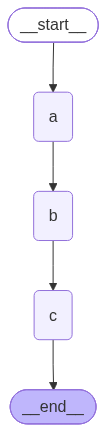


__copy__ 之后 calls = {'a': 2, 'b': 3, 'c': 3}   完全没变 = 节点没重跑
这个 fork 点 next = ('b',) ，messages = ['hi', 'A']

fork-demo 的检查点：
  step=-1  source=input  parent=-
  step=0  source=loop  parent=baf9b0
  step=1  source=loop  parent=5b6e61
  step=2  source=fork  parent=5b6e61
  step=2  source=loop  parent=ff0245
  step=3  source=loop  parent=fdea00


In [9]:
from IPython.display import Image, display
# 用副作用计数器验证：replay 会重跑节点，__copy__ 不会
calls = {"a": 0, "b": 0, "c": 0}


def counted(name, out):
    def fn(state):
        calls[name] += 1
        return {"messages": [("assistant", out)]}
    return fn


rb = StateGraph(MessagesState)
for n, o in (("a", "A"), ("b", "B"), ("c", "C")):
    rb.add_node(n, counted(n, o))
rb.add_edge(START, "a")
rb.add_edge("a", "b")
rb.add_edge("b", "c")
g2 = rb.compile(checkpointer=get_checkpointer())

# ---------- 1) replay：invoke(None, 旧 cfg) ----------
tid = "replay-demo"
get_checkpointer().delete_thread(tid)
g2.invoke({"messages": [("user", "hi")]}, {"configurable": {"thread_id": tid}})
print("正常跑完      calls =", calls)

snaps = list(get_checkpointer().list({"configurable": {"thread_id": tid}}))
old = [t for t in snaps if (t.metadata or {}).get("step") == 1][0]   # a 已跑、b 之前
old_cfg = {"configurable": {"thread_id": tid, "checkpoint_id": old.checkpoint["id"]}}

g2.invoke(None, old_cfg)          # ← replay
print("replay 之后   calls =", calls, "  b/c 都 +1 = 重跑了")

print("\nreplay 后的检查点：")
for t in sorted(get_checkpointer().list({"configurable": {"thread_id": tid}}),
                key=lambda x: (x.metadata or {}).get("step", -99)):
    md = t.metadata or {}
    print(f"  step={md.get('step')}  source={md.get('source')}"
          f"  parent={(t.parent_config or {}).get('configurable', {}).get('checkpoint_id', '-')[-6:]}")

# ---------- 2) fork：update_state(..., as_node="__copy__") ----------
tid2 = "fork-demo"
get_checkpointer().delete_thread(tid2)
g2.invoke({"messages": [("user", "hi")]}, {"configurable": {"thread_id": tid2}})
before = dict(calls)

snaps2 = list(get_checkpointer().list({"configurable": {"thread_id": tid2}}))
old2 = [t for t in snaps2 if (t.metadata or {}).get("step") == 1][0]
old_cfg2 = {"configurable": {"thread_id": tid2, "checkpoint_id": old2.checkpoint["id"]}}

# 注意是 update_state 的第 3 个位置参数 as_node
g2.update_state(old_cfg2, {"messages": [("assistant", "只改状态，不重跑")]}, as_node="__copy__")
display(Image(g2.get_graph().draw_mermaid_png()))
print("\n__copy__ 之后 calls =", calls, "  完全没变 = 节点没重跑")

copy_snap = g2.get_state(old_cfg2)
print("这个 fork 点 next =", copy_snap.next, "，messages =", [m.content for m in copy_snap.values["messages"]])

print("\nfork-demo 的检查点：")
for t in sorted(get_checkpointer().list({"configurable": {"thread_id": tid2}}),
                key=lambda x: (x.metadata or {}).get("step", -99)):
    md = t.metadata or {}
    print(f"  step={md.get('step')}  source={md.get('source')}"
          f"  parent={(t.parent_config or {}).get('configurable', {}).get('checkpoint_id', '-')[-6:]}")

从输出能看出三点：

1. **replay 后 `calls` 里 `b`、`c` 各 +1** —— 旧点之后的节点被重新执行了。**副作用会重放**（再调一次 LLM、再写一次 DB），这是 replay 最需要警惕的地方：只该用在「确定性推演」或「副作用可幂等」的图上。
2. **fork 点的 `parent` 指向历史 checkpoint**，原来的 `step=2/3` 那条链原封不动 —— 两条分支并存，这就是 append-only。
3. **`__copy__` 后 `calls` 纹丝不动** —— 它只是复制一份状态开新分支，适合「我想在某个历史点上微调状态、但不想重新花钱调模型」。

**怎么选**：

- 失败恢复 → `invoke(None, 断点 cfg)`（既不是 replay 也不是 fork，就是接着跑）
- 想看看「当初换个输入会怎样」→ replay，但注意副作用重放
- 想在历史点上改改状态继续 → `update_state(..., as_node="__copy__")`，省掉重跑成本
- 排查时想保留现场 → 用 `checkpoint_id` 切过去看 `get_state()`，只读不写，最安全

#### 失败治理的三档手段，怎么选

同一个「节点挂了」，有三种应对层级，**它们是叠加关系而不是替代**：

| 层级 | 手段 | 适用场景 | 详见 |
| --- | --- | --- | --- |
| ① 自动重试 | `RetryPolicy(max_attempts=3)` | 瞬时抖动：超时、限流、网络闪断 | `chapter02/06-重试机制.ipynb` |
| ② 降级兜底 | `error_handler` / 业务级预算 | 重试仍失败，但流程要走完（优雅降级） | `chapter02/06-重试机制.ipynb` |
| ③ 断点续跑 | `get_state()` + `invoke(None, cfg)` | 人要介入修复、或隔段时间再跑（本篇） | 本 notebook |

经验顺序：**先给 `llm_node` 挂 `RetryPolicy`**（大多数失败是瞬时的）→ 还不行才考虑 `error_handler` 兜底 → 需要人工修复或长任务中断时，用 checkpointer 断点续跑。

> 另一类「失败」是**步数超限**（`GraphRecursionError`），它同样能靠 checkpointer 抢救，机制见 `chapter02/05-AgentLoop.ipynb` 的「超限之后还能抢救」一节。

#### 小结

- 异常发生时 `invoke()` **不返回 state**，但故障前每步的 checkpoint 已落盘，`get_state(config)` 能拿到断点：`next` 指向挂掉的节点，`tasks[i].error` 是错误字符串。
- **`invoke(None, config)` 从断点续跑**，已完成的节点不会重跑；并行分支里成功的那半存在 `pending_writes`，续跑时直接采纳。
- 没挂 checkpointer 就没有断点，`get_state()` 直接 `ValueError: No checkpointer set`，只能整个重跑。
- 想重来而不是续跑，用 `checkpoint_id` 回到历史点 `invoke(None, old_cfg)`，会 `source=fork` 出一条新分支，原分支不受影响。
- 三档手段叠加使用：`RetryPolicy` 抗瞬时抖动 → `error_handler` 降级兜底 → checkpointer 断点续跑留给需要人工介入的场景。